In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import os
import sys
sys.path.append("/n/home12/binxuwang/Github/DiffusionAttnConsistency")
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch as th
import json
from tqdm import tqdm
from easydict import EasyDict as edict
from core.parity_lib import parity_func, round_to_pos_neg_one
from circuit_toolkit import saveallforms

/n/home12/binxuwang/Github/circuit_toolkit/circuit_toolkit/GAN_invert_utils.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange, tqdm


### Demo

In [3]:
saveroot = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
exp_name = f"DiT_mini_parity_N4096_D36_G36_even"
savedir = f"{saveroot}/{exp_name}"
sample_dir = f"{savedir}/samples"
ckpt_dir = f"{savedir}/ckpts"

In [ ]:
sample_tsr = th.load(f"{sample_dir}/samples_epoch_050000.pt")
sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=1e-2)
sample_eval_parity = parity_func(sample_tsr_int.flatten(1), axis=1)
sample_num = len(sample_eval_parity)
even_parity_num = th.sum(sample_eval_parity == 0).item()
odd_parity_num = th.sum(sample_eval_parity == 1).item()
nan_num = th.sum(th.isnan(sample_eval_parity)).item()
print(f"Even parity: {even_parity_num}, Odd parity: {odd_parity_num} nan: {nan_num}| total: {sample_num}")

Even parity: 1023, Odd parity: 1007 nan: 18| total: 2048


/tmp/ipykernel_1879570/4248371688.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample_tsr = th.load(f"{sample_dir}/samples_epoch_050000.pt")


In [47]:
eval_stats = []
for step in [1, *range(1000, 50001, 1000)]:
    sample_tsr = th.load(f"{sample_dir}/samples_epoch_{step:06d}.pt")
    eps = 1e-1
    sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
    sample_eval_parity = parity_func(sample_tsr_int.flatten(1), axis=1)
    sample_num = len(sample_eval_parity)
    even_parity_num_eps_1e_1 = th.sum(sample_eval_parity == 0).item()
    odd_parity_num_eps_1e_1 = th.sum(sample_eval_parity == 1).item()
    nan_num_eps_1e_1 = th.sum(th.isnan(sample_eval_parity)).item()
    print(f"Even parity: {even_parity_num_eps_1e_1}, Odd parity: {odd_parity_num_eps_1e_1} nan: {nan_num_eps_1e_1}| total: {sample_num}")
    
    eps = 1e-2
    sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
    sample_eval_parity = parity_func(sample_tsr_int.flatten(1), axis=1)
    sample_num = len(sample_eval_parity)
    even_parity_num_eps_1e_2 = th.sum(sample_eval_parity == 0).item()
    odd_parity_num_eps_1e_2 = th.sum(sample_eval_parity == 1).item()
    nan_num_eps_1e_2 = th.sum(th.isnan(sample_eval_parity)).item()
    print(f"Even parity: {even_parity_num_eps_1e_2}, Odd parity: {odd_parity_num_eps_1e_2} nan: {nan_num_eps_1e_2}| total: {sample_num}")
    eval_stats.append({
        "step": step,
        "sample_num": sample_num,
        "even_parity_num_eps_1e-2": even_parity_num_eps_1e_2,
        "odd_parity_num_eps_1e-2": odd_parity_num_eps_1e_2,
        "nan_num_eps_1e-2": nan_num_eps_1e_2,
        "even_parity_num_eps_1e-1": even_parity_num_eps_1e_1,
        "odd_parity_num_eps_1e-1": odd_parity_num_eps_1e_1,
        "nan_num_eps_1e-1": nan_num_eps_1e_1,
    })
# th.save(eval_stats, f"{savedir}/eval_stats.pt")
eval_stats_df = pd.DataFrame(eval_stats)
eval_stats_df.to_csv(f"{savedir}/eval_stats.csv", index=False)

Even parity: 0, Odd parity: 0 nan: 2048| total: 2048
Even parity: 0, Odd parity: 0 nan: 2048| total: 2048
Even parity: 958, Odd parity: 1007 nan: 83| total: 2048
Even parity: 8, Odd parity: 8 nan: 2032| total: 2048
Even parity: 1007, Odd parity: 988 nan: 53| total: 2048
Even parity: 127, Odd parity: 104 nan: 1817| total: 2048
Even parity: 981, Odd parity: 1026 nan: 41| total: 2048
Even parity: 82, Odd parity: 99 nan: 1867| total: 2048
Even parity: 990, Odd parity: 1031 nan: 27| total: 2048
Even parity: 37, Odd parity: 41 nan: 1970| total: 2048
Even parity: 991, Odd parity: 1036 nan: 21| total: 2048
Even parity: 76, Odd parity: 83 nan: 1889| total: 2048
Even parity: 1007, Odd parity: 1032 nan: 9| total: 2048
Even parity: 110, Odd parity: 103 nan: 1835| total: 2048
Even parity: 993, Odd parity: 1047 nan: 8| total: 2048
Even parity: 367, Odd parity: 379 nan: 1302| total: 2048
Even parity: 998, Odd parity: 1033 nan: 17| total: 2048
Even parity: 427, Odd parity: 491 nan: 1130| total: 2048
E

/tmp/ipykernel_1879570/2725671738.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample_tsr = th.load(f"{sample_dir}/samples_epoch_{step:06d}.pt")


In [48]:
eval_stats_df

,step,sample_num,even_parity_num_eps_1e-2,odd_parity_num_eps_1e-2,nan_num_eps_1e-2,even_parity_num_eps_1e-1,odd_parity_num_eps_1e-1,nan_num_eps_1e-1
0,1,2048,0,0,2048,0,0,2048
1,1000,2048,8,8,2032,958,1007,83
2,2000,2048,127,104,1817,1007,988,53
3,3000,2048,82,99,1867,981,1026,41
4,4000,2048,37,41,1970,990,1031,27
5,5000,2048,76,83,1889,991,1036,21
6,6000,2048,110,103,1835,1007,1032,9
7,7000,2048,367,379,1302,993,1047,8
8,8000,2048,427,491,1130,998,1033,17
9,9000,2048,335,300,1413,1063,978,7


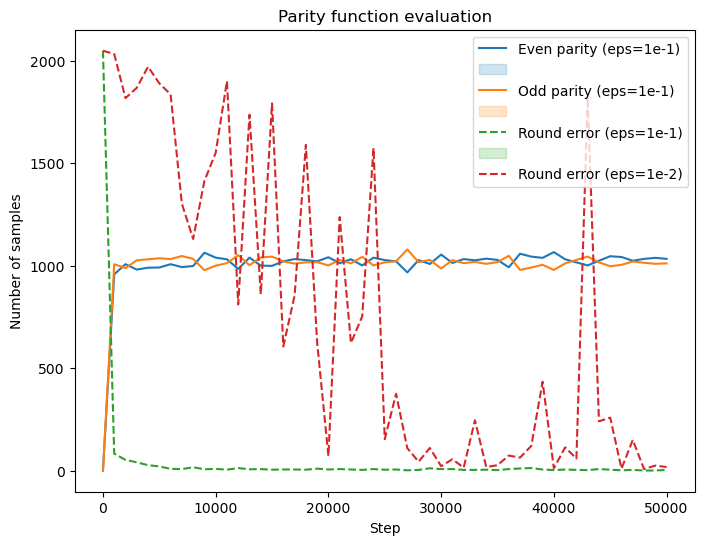

In [ ]:
plt.figure(figsize=(8, 6))
sns.lineplot(x="step", y="even_parity_num_eps_1e-1", data=eval_stats_df)
sns.lineplot(x="step", y="odd_parity_num_eps_1e-1", data=eval_stats_df)
sns.lineplot(x="step", y="nan_num_eps_1e-1", data=eval_stats_df, linestyle="--")
sns.lineplot(x="step", y="nan_num_eps_1e-2", data=eval_stats_df, linestyle="--")
plt.legend(labels=["Even parity (eps=1e-1)", "", "Odd parity (eps=1e-1)", "", "Round error (eps=1e-1)","", "Round error (eps=1e-2)"])
plt.xlabel("Step")
plt.ylabel("Number of samples")
plt.title("Parity function evaluation")
plt.show()

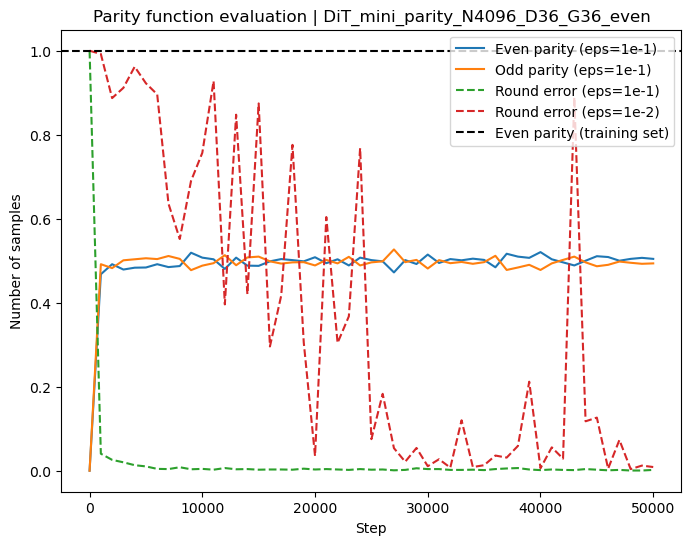

In [59]:
eval_stats_df['even_parity_ratio_eps_1e-1'] = eval_stats_df['even_parity_num_eps_1e-1'] / eval_stats_df['sample_num']
eval_stats_df['odd_parity_ratio_eps_1e-1'] = eval_stats_df['odd_parity_num_eps_1e-1'] / eval_stats_df['sample_num']
eval_stats_df['nan_ratio_eps_1e-1'] = eval_stats_df['nan_num_eps_1e-1'] / eval_stats_df['sample_num']
eval_stats_df['nan_ratio_eps_1e-2'] = eval_stats_df['nan_num_eps_1e-2'] / eval_stats_df['sample_num']

plt.figure(figsize=(8, 6))
sns.lineplot(x="step", y="even_parity_ratio_eps_1e-1", data=eval_stats_df, label="Even parity (eps=1e-1)")
sns.lineplot(x="step", y="odd_parity_ratio_eps_1e-1", data=eval_stats_df, label="Odd parity (eps=1e-1)")
sns.lineplot(x="step", y="nan_ratio_eps_1e-1", data=eval_stats_df, linestyle="--", label="Round error (eps=1e-1)")
sns.lineplot(x="step", y="nan_ratio_eps_1e-2", data=eval_stats_df, linestyle="--", label="Round error (eps=1e-2)")
plt.axhline(y=1.0, color="black", linestyle="--", label="Even parity (training set)")
# plt.legend(labels=["Even parity (eps=1e-1)", "", "Odd parity (eps=1e-1)", "", "Round error (eps=1e-1)","", "Round error (eps=1e-2)"])
plt.legend()
plt.xlabel("Step")
plt.ylabel("Number of samples")
plt.title(f"Parity function evaluation | {exp_name}")
plt.show()

In [38]:
sample_tsr

tensor([[[[ 0.9993, -1.0015, -1.0021,  0.9991,  0.9996, -0.9997],
          [-1.0017,  0.9989,  0.9989,  0.9992, -1.0012,  0.9988],
          [-1.0023,  0.9987,  0.9989, -1.0024, -1.0022,  0.9994],
          [ 0.9992,  0.9990,  0.9988, -1.0031,  0.9992,  0.9998],
          [-1.0021,  0.9999,  0.9999,  1.0000,  0.9999, -1.0009],
          [ 0.9996, -1.0025, -1.0022,  1.0002, -1.0013, -1.0007]]],


        [[[ 1.0014, -0.9978, -0.9982, -0.9977,  1.0013,  1.0011],
          [-0.9980, -0.9985, -0.9983,  1.0001, -0.9981, -0.9967],
          [ 0.9998,  1.0000, -0.9991, -0.9989, -0.9984, -0.9977],
          [-0.9986,  0.9997, -0.9992, -0.9992,  0.9997,  1.0000],
          [-0.9980, -0.9986,  0.9999, -0.9991,  1.0001,  1.0004],
          [ 1.0006, -0.9984,  1.0009, -0.9984, -0.9977, -0.9968]]],


        [[[-0.9966, -0.9977, -0.9973, -0.9980, -0.9969, -0.9955],
          [-0.9983, -0.9980,  0.9999, -0.9977, -0.9972, -0.9966],
          [-0.9982,  1.0001, -0.9990, -0.9992, -0.9980,  0.9997],
  

### Mass produce

In [4]:
saveroot = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"

In [5]:
os.listdir(saveroot)

['DiT_mini_parity_N4096_D36_G2_even',
 'DiT_mini_parity_N4096_D36_G4_even',
 'DiT_mini_parity_N4096_D36_G12_even',
 'DiT_mini_parity_N4096_D36_G9_even',
 'DiT_mini_parity_N4096_D36_G3_even',
 'DiT_mini_parity_N4096_D36_G36_even',
 'DiT_mini_parity_N4096_D36_G6_even',
 'DiT_mini_parity_N4096_D36_G18_even']

In [4]:
def get_all_available_steps(sample_dir, excluded_steps=[]):
    """Get all available step numbers from sample files in the directory."""
    sample_files = [f for f in os.listdir(sample_dir) if f.startswith("samples_epoch_") and f.endswith(".pt")]
    steps = []
    for f in sample_files:
        step_str = f.replace("samples_epoch_", "").replace(".pt", "")
        steps.append(int(step_str))
    steps = sorted(steps)
    steps = [step for step in steps if step not in excluded_steps]
    return steps

# Get available steps
steps = get_all_available_steps(sample_dir)
# print(f"Available steps: {steps}")

In [ ]:
saveroot = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
for exp_name in ['DiT_mini_parity_N4096_D36_G2_even',
                'DiT_mini_parity_N4096_D36_G3_even',
                'DiT_mini_parity_N4096_D36_G4_even',
                'DiT_mini_parity_N4096_D36_G6_even',
                'DiT_mini_parity_N4096_D36_G9_even',
                'DiT_mini_parity_N4096_D36_G12_even',
                'DiT_mini_parity_N4096_D36_G18_even',
                'DiT_mini_parity_N4096_D36_G36_even',]:
    savedir = f"{saveroot}/{exp_name}"
    sample_dir = f"{savedir}/samples"
    ckpt_dir = f"{savedir}/ckpts"
    config = json.load(open(f"{savedir}/config.json"))
    args = edict(json.load(open(f"{savedir}/args.json")))
    sample_num = args.sample_num
    sample_len = args.sample_len
    group_size = args.group_size
    parity = args.parity
    Xtsr = th.load(f"{savedir}/training_data_tsr.pt", weights_only=False)

### Old global eval version

In [25]:
def sweep_eval_all_samples(savedir, excluded_steps=[], verbose=False):
    sample_dir = f"{savedir}/samples"
    eval_stats = []
    # fetch all steps
    all_steps = get_all_available_steps(sample_dir, excluded_steps=excluded_steps)
    pbar = tqdm(all_steps)
    for step in pbar:
        sample_tsr = th.load(f"{sample_dir}/samples_epoch_{step:06d}.pt")
        eps = 1e-1
        sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
        sample_eval_parity = parity_func(sample_tsr_int.flatten(1), axis=1)
        sample_num = len(sample_eval_parity)
        even_parity_num_eps_1e_1 = th.sum(sample_eval_parity == 0).item()
        odd_parity_num_eps_1e_1 = th.sum(sample_eval_parity == 1).item()
        nan_num_eps_1e_1 = th.sum(th.isnan(sample_eval_parity)).item()
        if verbose:
            print(f"Even parity: {even_parity_num_eps_1e_1}, Odd parity: {odd_parity_num_eps_1e_1} nan: {nan_num_eps_1e_1}| total: {sample_num}")
        pbar.set_description(f"step: {step}, Even: {even_parity_num_eps_1e_1}, Odd: {odd_parity_num_eps_1e_1} nan: {nan_num_eps_1e_1}| total: {sample_num}")
        
        eps = 1e-2
        sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
        sample_eval_parity = parity_func(sample_tsr_int.flatten(1), axis=1)
        sample_num = len(sample_eval_parity)
        even_parity_num_eps_1e_2 = th.sum(sample_eval_parity == 0).item()
        odd_parity_num_eps_1e_2 = th.sum(sample_eval_parity == 1).item()
        nan_num_eps_1e_2 = th.sum(th.isnan(sample_eval_parity)).item()
        if verbose:
            print(f"Even parity: {even_parity_num_eps_1e_2}, Odd parity: {odd_parity_num_eps_1e_2} nan: {nan_num_eps_1e_2}| total: {sample_num}")
        eval_stats.append({
            "step": step,
            "sample_num": sample_num,
            "even_parity_num_eps_1e-2": even_parity_num_eps_1e_2,
            "odd_parity_num_eps_1e-2": odd_parity_num_eps_1e_2,
            "nan_num_eps_1e-2": nan_num_eps_1e_2,
            "even_parity_num_eps_1e-1": even_parity_num_eps_1e_1,
            "odd_parity_num_eps_1e-1": odd_parity_num_eps_1e_1,
            "nan_num_eps_1e-1": nan_num_eps_1e_1,
        })
    # th.save(eval_stats, f"{savedir}/eval_stats.pt")
    eval_stats_df = pd.DataFrame(eval_stats)
    eval_stats_df.to_csv(f"{savedir}/eval_stats.csv", index=False)
    return eval_stats_df

In [26]:
saveroot = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
os.makedirs(f"{saveroot}/synopsis", exist_ok=True)
synopsis_dir = f"/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures"

In [29]:
saveroot = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
eval_stats_df_all = []
for exp_name in [#'DiT_mini_parity_N4096_D36_G2_even',
                #'DiT_mini_parity_N4096_D36_G3_even',
                #'DiT_mini_parity_N4096_D36_G4_even',
                #'DiT_mini_parity_N4096_D36_G6_even',
                #'DiT_mini_parity_N4096_D36_G9_even',
                #'DiT_mini_parity_N4096_D36_G12_even',
                #'DiT_mini_parity_N4096_D36_G18_even',
                'DiT_mini_parity_N4096_D36_G36_even',]:
    savedir = f"{saveroot}/{exp_name}"
    sample_dir = f"{savedir}/samples"
    ckpt_dir = f"{savedir}/ckpts"
    config = json.load(open(f"{savedir}/config.json"))
    args = edict(json.load(open(f"{savedir}/args.json")))
    sample_num = args.sample_num
    sample_len = args.sample_len
    group_size = args.group_size
    parity = args.parity
    Xtsr = th.load(f"{savedir}/training_data_tsr.pt", weights_only=False)
    eval_stats_df = sweep_eval_all_samples(savedir, excluded_steps=[], verbose=False)
    eval_stats_df['exp_name'] = exp_name
    eval_stats_df['group_size'] = group_size
    eval_stats_df['sample_num'] = sample_num
    eval_stats_df_all.append(eval_stats_df)

eval_stats_df_all = pd.concat(eval_stats_df_all)
eval_stats_df_all.to_csv(f"{saveroot}/synopsis/eval_stats_all.csv", index=False)
eval_stats_df_all.to_csv(f"{synopsis_dir}/eval_stats_all.csv", index=False)

  0%|          | 0/974 [00:00<?, ?it/s]/tmp/ipykernel_2061250/2328847142.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample_tsr = th.load(f"{sample_dir}/samples_epoc

### Current group wise version 

In [5]:
sorted(os.listdir(saveroot,))

['DiT_S_parity_N4096_D36_G12_even',
 'DiT_S_parity_N4096_D36_G18_even',
 'DiT_S_parity_N4096_D36_G2_even',
 'DiT_S_parity_N4096_D36_G36_even',
 'DiT_S_parity_N4096_D36_G3_even',
 'DiT_S_parity_N4096_D36_G4_even',
 'DiT_S_parity_N4096_D36_G6_even',
 'DiT_S_parity_N4096_D36_G9_even',
 'DiT_mini_parity_N4096_D36_G12_even',
 'DiT_mini_parity_N4096_D36_G18_even',
 'DiT_mini_parity_N4096_D36_G2_even',
 'DiT_mini_parity_N4096_D36_G36_even',
 'DiT_mini_parity_N4096_D36_G3_even',
 'DiT_mini_parity_N4096_D36_G4_even',
 'DiT_mini_parity_N4096_D36_G6_even',
 'DiT_mini_parity_N4096_D36_G9_even',
 'DiT_nano_parity_N4096_D36_G12_even',
 'DiT_nano_parity_N4096_D36_G18_even',
 'DiT_nano_parity_N4096_D36_G2_even',
 'DiT_nano_parity_N4096_D36_G36_even',
 'DiT_nano_parity_N4096_D36_G3_even',
 'DiT_nano_parity_N4096_D36_G4_even',
 'DiT_nano_parity_N4096_D36_G6_even',
 'DiT_nano_parity_N4096_D36_G9_even',
 'pergroup_eval_stats_all_exps.csv',
 'synopsis']

In [6]:
synopsis_dir = f"/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures"

step: 1000000, Per group parity correctness: 36859, Sample correctness: 2043 nan: 4| total: 2048: 100%|██████████| 1472/1472 [00:45<00:00, 32.10it/s]


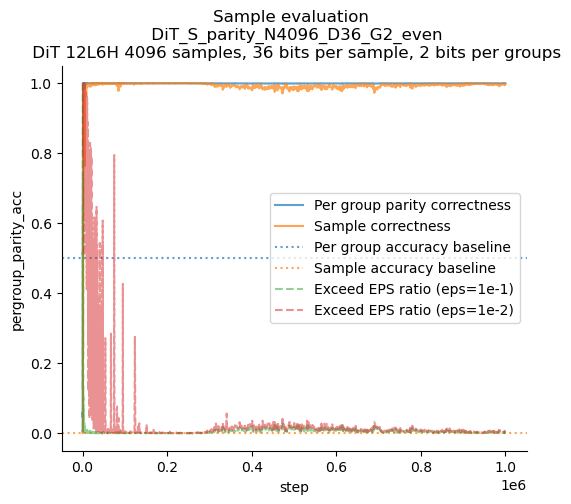

step: 1000000, Per group parity correctness: 24518, Sample correctness: 1991 nan: 9| total: 2048: 100%|██████████| 1472/1472 [00:45<00:00, 32.23it/s]


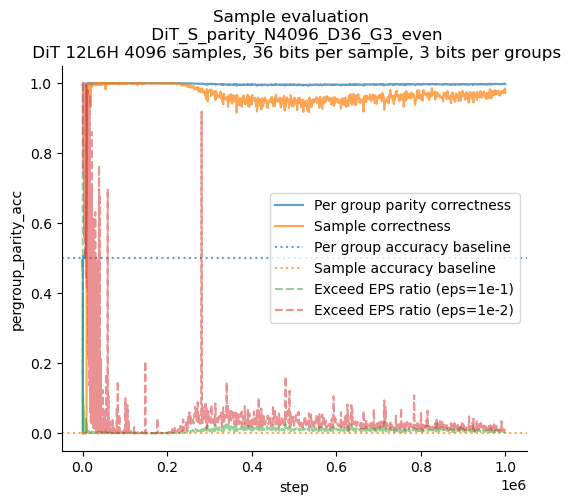

step: 1000000, Per group parity correctness: 18360, Sample correctness: 1977 nan: 1| total: 2048: 100%|██████████| 1472/1472 [00:45<00:00, 32.39it/s]


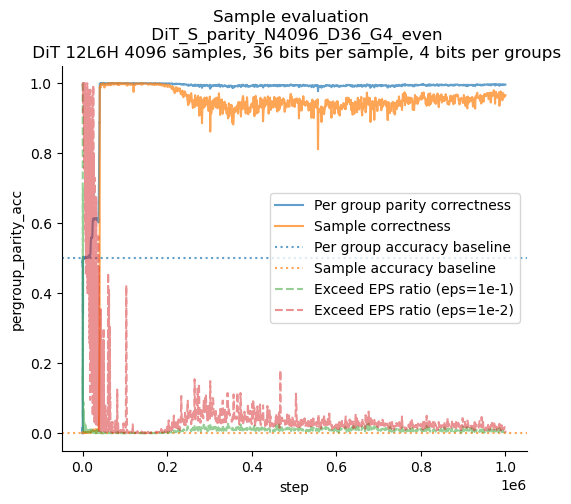

step: 1000000, Per group parity correctness: 12184, Sample correctness: 1948 nan: 4| total: 2048: 100%|██████████| 1472/1472 [00:44<00:00, 32.91it/s]


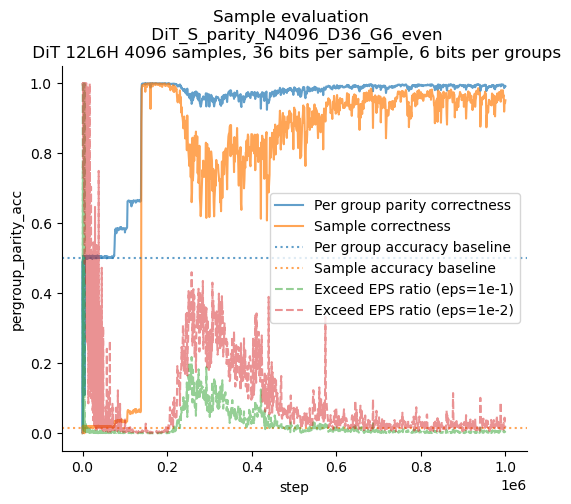

step: 1000000, Per group parity correctness: 7119, Sample correctness: 1408 nan: 5| total: 2048: 100%|██████████| 1472/1472 [00:44<00:00, 33.43it/s]


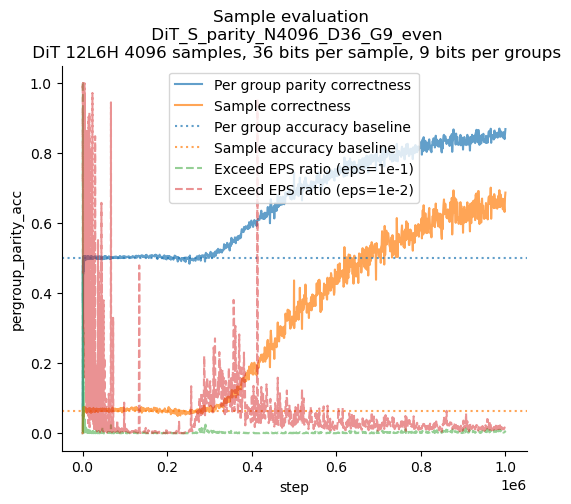

step: 1000000, Per group parity correctness: 5406, Sample correctness: 1547 nan: 42| total: 2048: 100%|██████████| 1472/1472 [00:44<00:00, 33.35it/s]


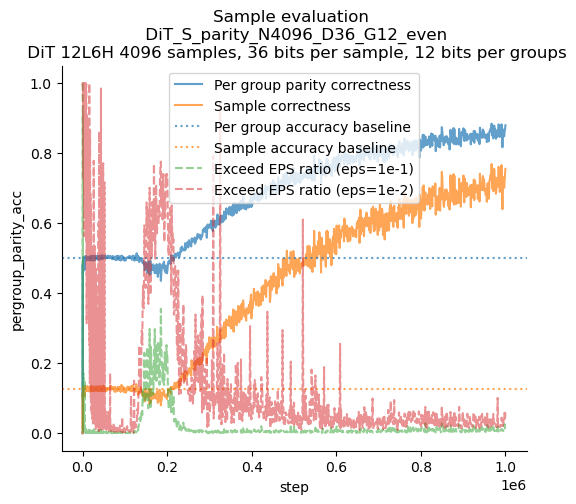

step: 1000000, Per group parity correctness: 3423, Sample correctness: 1503 nan: 8| total: 2048: 100%|██████████| 1472/1472 [00:46<00:00, 31.64it/s]


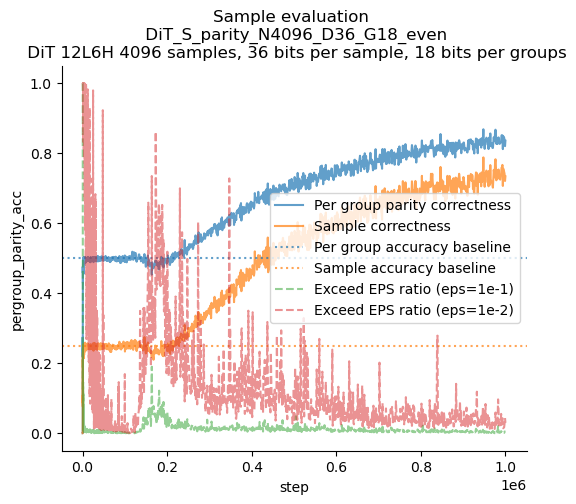

step: 1000000, Per group parity correctness: 1669, Sample correctness: 1669 nan: 32| total: 2048: 100%|██████████| 1472/1472 [00:46<00:00, 31.72it/s]


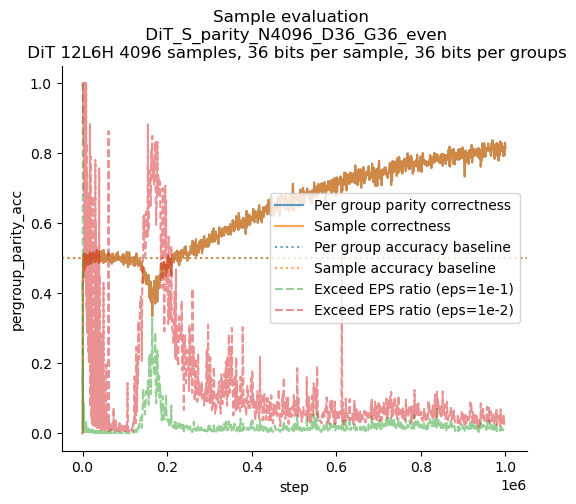

step: 1000000, Per group parity correctness: 36855, Sample correctness: 2039 nan: 4| total: 2048: 100%|██████████| 1471/1471 [00:42<00:00, 35.00it/s]


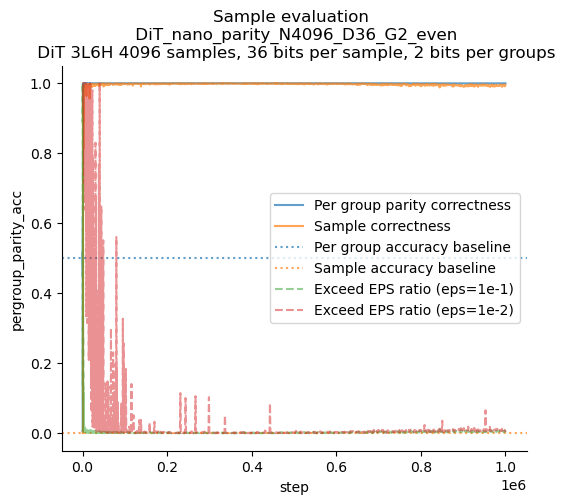

step: 1000000, Per group parity correctness: 24519, Sample correctness: 1992 nan: 29| total: 2048: 100%|██████████| 1471/1471 [00:40<00:00, 36.49it/s]


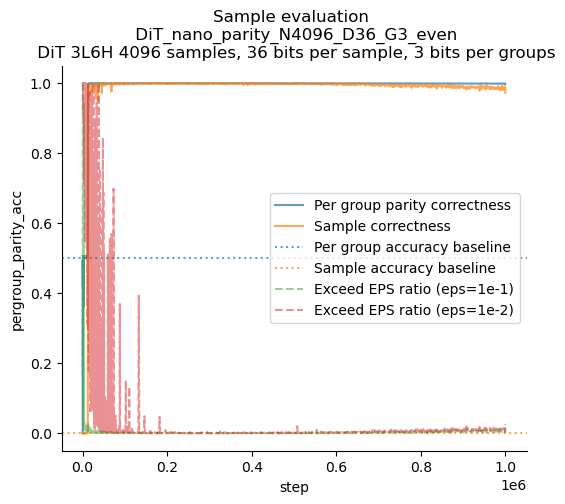

step: 1000000, Per group parity correctness: 18324, Sample correctness: 1944 nan: 23| total: 2048: 100%|██████████| 1471/1471 [00:42<00:00, 34.68it/s]


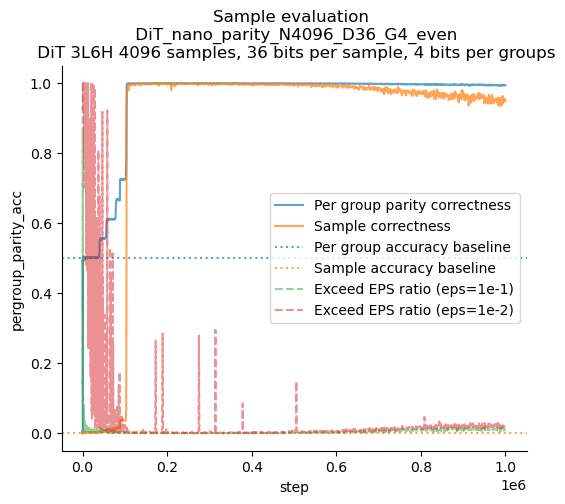

step: 1000000, Per group parity correctness: 8057, Sample correctness: 197 nan: 5| total: 2048: 100%|██████████| 1471/1471 [00:43<00:00, 33.83it/s]


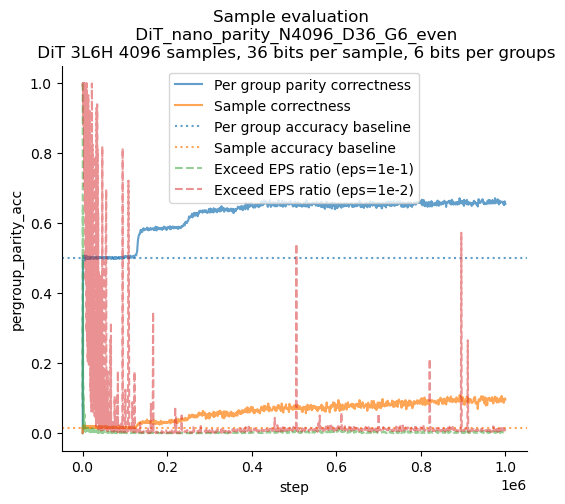

step: 1000000, Per group parity correctness: 4458, Sample correctness: 229 nan: 7| total: 2048: 100%|██████████| 1471/1471 [00:41<00:00, 35.51it/s]


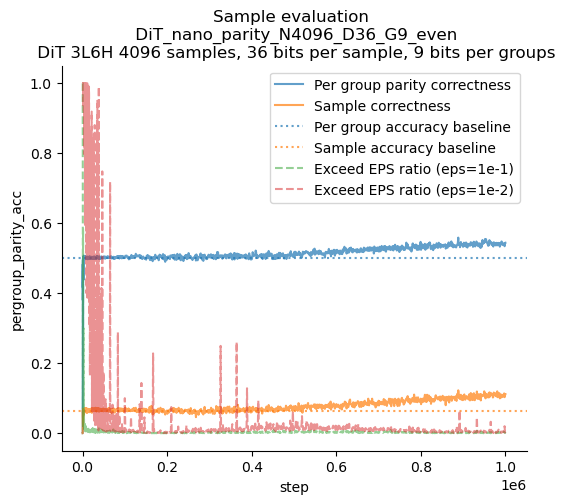

step: 1000000, Per group parity correctness: 3270, Sample correctness: 348 nan: 3| total: 2048: 100%|██████████| 1471/1471 [00:32<00:00, 44.87it/s]


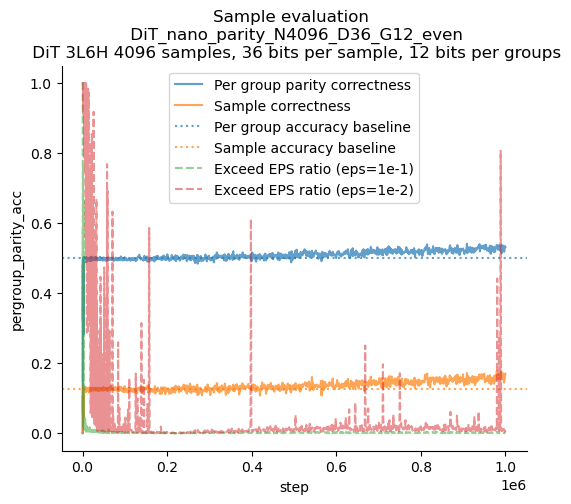

step: 1000000, Per group parity correctness: 2153, Sample correctness: 558 nan: 3| total: 2048: 100%|██████████| 1471/1471 [00:33<00:00, 43.97it/s]


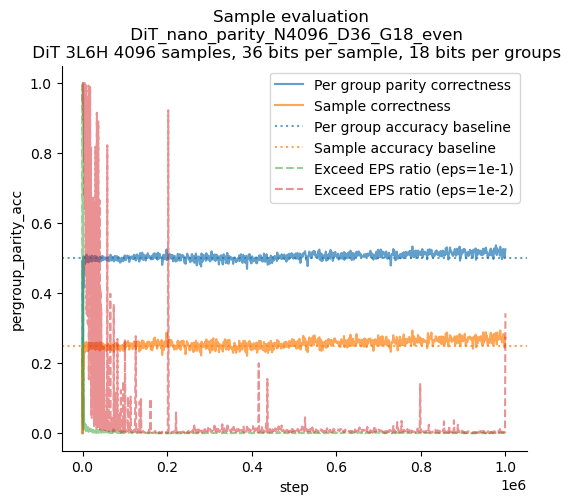

step: 1000000, Per group parity correctness: 1065, Sample correctness: 1065 nan: 1| total: 2048: 100%|██████████| 1471/1471 [00:33<00:00, 43.64it/s]


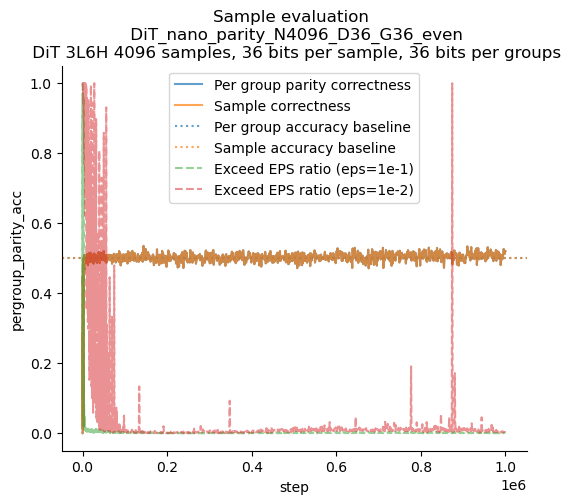

step: 1000000, Per group parity correctness: 36849, Sample correctness: 2033 nan: 12| total: 2048: 100%|██████████| 1472/1472 [00:47<00:00, 30.69it/s]


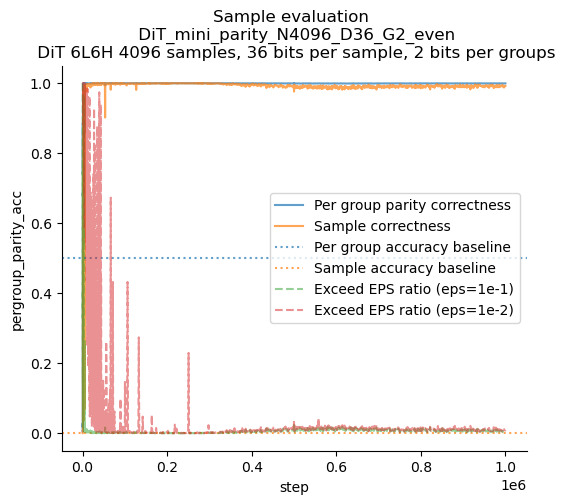

step: 1000000, Per group parity correctness: 24519, Sample correctness: 1991 nan: 15| total: 2048: 100%|██████████| 1472/1472 [00:45<00:00, 32.71it/s]


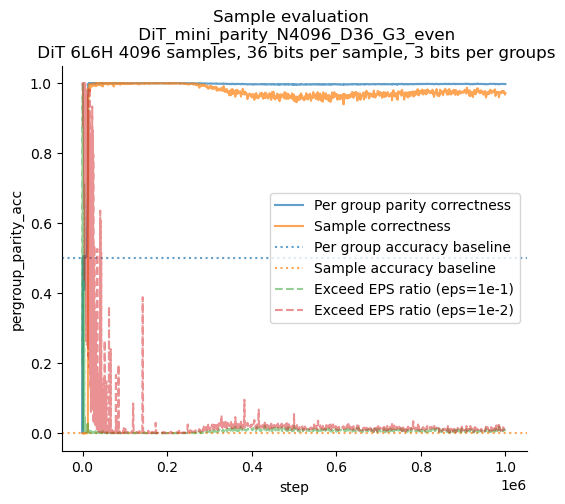

step: 1000000, Per group parity correctness: 18378, Sample correctness: 1994 nan: 8| total: 2048: 100%|██████████| 1472/1472 [00:43<00:00, 34.10it/s]


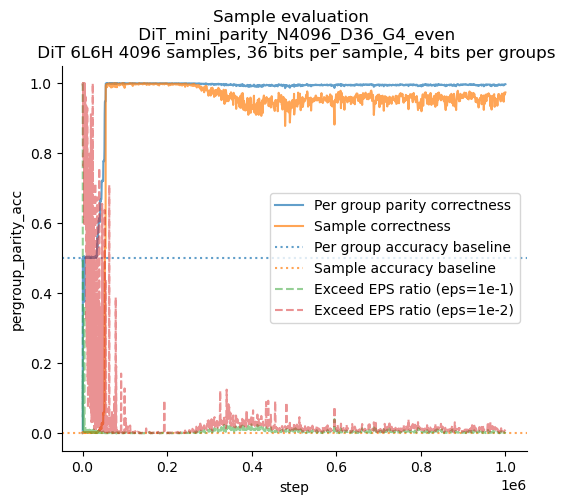

step: 1000000, Per group parity correctness: 9981, Sample correctness: 887 nan: 50| total: 2048: 100%|██████████| 1472/1472 [00:43<00:00, 34.05it/s] 


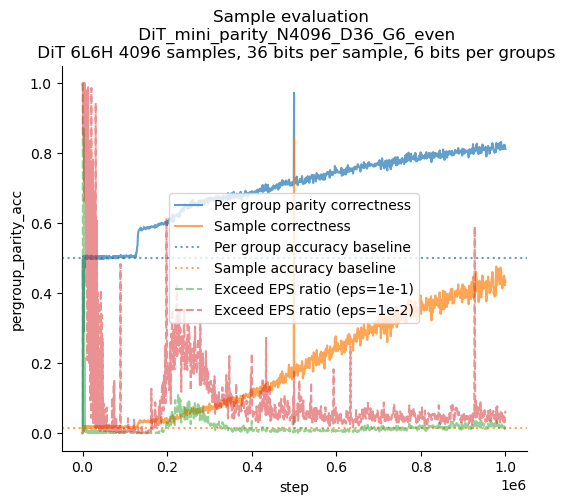

step: 1000000, Per group parity correctness: 6301, Sample correctness: 1042 nan: 9| total: 2048: 100%|██████████| 1472/1472 [00:43<00:00, 33.57it/s]


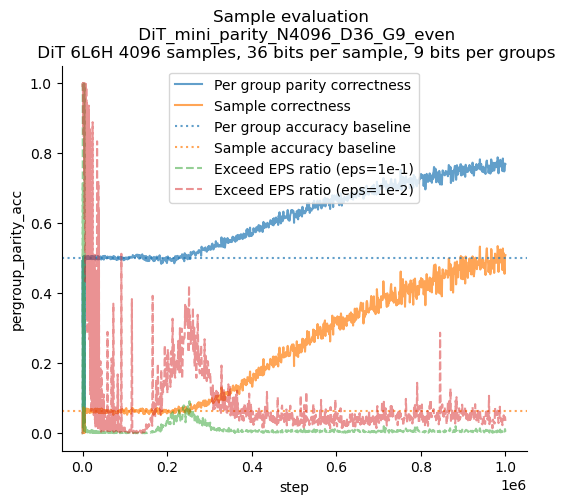

step: 1000000, Per group parity correctness: 4567, Sample correctness: 1039 nan: 24| total: 2048: 100%|██████████| 1472/1472 [00:41<00:00, 35.53it/s]


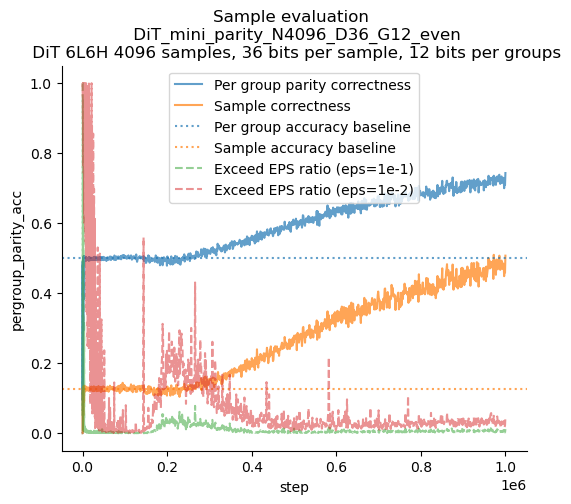

step: 1000000, Per group parity correctness: 2887, Sample correctness: 1126 nan: 11| total: 2048: 100%|██████████| 1472/1472 [00:39<00:00, 37.55it/s]


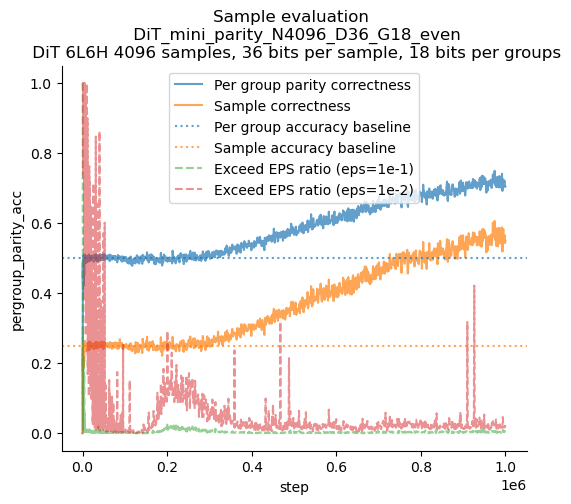

step: 1000000, Per group parity correctness: 1291, Sample correctness: 1291 nan: 83| total: 2048: 100%|██████████| 1518/1518 [00:41<00:00, 36.35it/s]


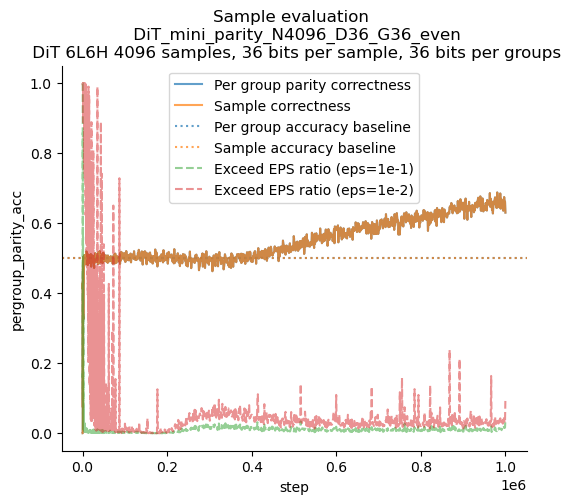

In [20]:
saveroot = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
eval_stats_df_all = []
for exp_name in [
                #
                'DiT_S_parity_N4096_D36_G2_even',
                'DiT_S_parity_N4096_D36_G3_even',
                'DiT_S_parity_N4096_D36_G4_even',
                'DiT_S_parity_N4096_D36_G6_even',
                'DiT_S_parity_N4096_D36_G9_even',
                'DiT_S_parity_N4096_D36_G12_even',
                'DiT_S_parity_N4096_D36_G18_even',
                'DiT_S_parity_N4096_D36_G36_even',
                #
                'DiT_nano_parity_N4096_D36_G2_even',
                'DiT_nano_parity_N4096_D36_G3_even',
                'DiT_nano_parity_N4096_D36_G4_even',
                'DiT_nano_parity_N4096_D36_G6_even',
                'DiT_nano_parity_N4096_D36_G9_even',
                'DiT_nano_parity_N4096_D36_G12_even',
                'DiT_nano_parity_N4096_D36_G18_even',
                'DiT_nano_parity_N4096_D36_G36_even',
                # 
                'DiT_mini_parity_N4096_D36_G2_even',
                'DiT_mini_parity_N4096_D36_G3_even',
                'DiT_mini_parity_N4096_D36_G4_even',
                'DiT_mini_parity_N4096_D36_G6_even',
                'DiT_mini_parity_N4096_D36_G9_even',
                'DiT_mini_parity_N4096_D36_G12_even',
                'DiT_mini_parity_N4096_D36_G18_even',
                'DiT_mini_parity_N4096_D36_G36_even',]:
    savedir = f"{saveroot}/{exp_name}"
    sample_dir = f"{savedir}/samples"
    ckpt_dir = f"{savedir}/ckpts"
    args = edict(json.load(open(f"{savedir}/args.json")))
    config = json.load(open(f"{savedir}/config.json"))
    train_sample_num = args.sample_num
    sample_len = args.sample_len
    group_size = args.group_size
    num_groups = sample_len // group_size
    nlayer = config["depth"]
    nhead  = config["num_heads"]
    parity = args.parity
    eval_stats = []
    all_steps = get_all_available_steps(sample_dir, excluded_steps=[])
    pbar = tqdm(all_steps)
    for step in pbar:
        sample_tsr = th.load(f"{sample_dir}/samples_epoch_{step:06d}.pt", weights_only=False)
        eval_sample_num = sample_tsr.shape[0]
        eps = 1e-2
        sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
        exist_nan = th.sum(sample_tsr_int.flatten(start_dim=1), dim=1)
        nan_num_eps_1e_2 = th.sum(th.isnan(exist_nan)).item()
        nan_ratio_eps_1e_2 = nan_num_eps_1e_2 / eval_sample_num
        
        eps = 1e-1
        sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
        exist_nan = th.sum(sample_tsr_int.flatten(start_dim=1), dim=1)
        nan_num_eps_1e_1 = th.sum(th.isnan(exist_nan)).item()
        nan_ratio_eps_1e_1 = nan_num_eps_1e_1 / eval_sample_num
        # reshape to group as last dimension
        sample_pergroup_int = sample_tsr_int.reshape(eval_sample_num, num_groups, group_size)
        sample_eval_parity = parity_func(sample_pergroup_int, axis=-1)
        # count parity correctness for each group
        pergroup_parity_correctness = th.sum(sample_eval_parity == parity).sum()
        pergroup_parity_correctness_ratio = pergroup_parity_correctness / (eval_sample_num * num_groups)
        # count sample correct only when all groups are correct
        sample_correctness = th.all(sample_eval_parity == parity, dim=1).sum()
        sample_correctness_ratio = sample_correctness / eval_sample_num
        pbar.set_description(f"step: {step}, Per group parity correctness: {pergroup_parity_correctness}, Sample correctness: {sample_correctness} nan: {nan_num_eps_1e_1}| total: {eval_sample_num}")
        
        # correct_parity_pergroup = th.sum(sample_eval_parity == 0, axis=-1) / group_size
        # correct_parity_pergroup_ratio = correct_parity_pergroup / num_groups
        # correct_parity_pergroup_ratio_ratio = correct_parity_pergroup_ratio / group_size
        # nan_pergroup = th.sum(th.isnan(sample_eval_parity), axis=-1)
        # nan_pergroup_ratio = nan_pergroup / num_groups
        # nan_pergroup_ratio_ratio = nan_pergroup_ratio / group_size
        # print(f"Even parity: {even_parity_num_eps_1e_1}, Odd parity: {odd_parity_num_eps_1e_1} nan: {nan_num_eps_1e_1}| total: {sample_num}")
        # eps = 1e-2
        # sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
        # sample_eval_parity = parity_func(sample_tsr_int.flatten(1), axis=1)
        # sample_num = len(sample_eval_parity)
        # even_parity_num_eps_1e_2 = th.sum(sample_eval_parity == 0).item()
        # odd_parity_num_eps_1e_2 = th.sum(sample_eval_parity == 1).item()
        # nan_num_eps_1e_2 = th.sum(th.isnan(sample_eval_parity)).item()
        # print(f"Even parity: {even_parity_num_eps_1e_2}, Odd parity: {odd_parity_num_eps_1e_2} nan: {nan_num_eps_1e_2}| total: {sample_num}")
        eval_stats.append({
            "step": step,
            "sample_num": eval_sample_num,
            "group_size": group_size,
            "nan_num_eps_1e-1": nan_num_eps_1e_1,
            "nan_ratio_eps_1e-1": nan_ratio_eps_1e_1,
            "nan_num_eps_1e-2": nan_num_eps_1e_2,
            "nan_ratio_eps_1e-2": nan_ratio_eps_1e_2,
            "pergroup_parity_num": pergroup_parity_correctness.item(),
            "pergroup_parity_acc": pergroup_parity_correctness_ratio.item(),
            "sample_corr_num": sample_correctness.item(),
            "sample_corr_acc": sample_correctness_ratio.item(),
        })
    # th.save(eval_stats, f"{savedir}/eval_stats.pt")
    eval_stats_df = pd.DataFrame(eval_stats)
    eval_stats_df.to_csv(f"{savedir}/pergroup_eval_stats.csv", index=False)
    eval_stats_df["exp_name"] = exp_name
    eval_stats_df["group_size"] = group_size
    eval_stats_df_all.append(eval_stats_df)
    plt.figure(figsize=(6, 5))
    sns.lineplot(eval_stats_df, x="step", y="pergroup_parity_acc",  label="Per group parity correctness", alpha=0.7) # hue="group_size",
    sns.lineplot(eval_stats_df, x="step", y="sample_corr_acc",  label="Sample correctness", alpha=0.7) # hue="group_size",
    plt.axhline(y=0.5, linestyle=":", label="Per group accuracy baseline", color="C0", alpha=0.7)
    plt.axhline(y=0.5 ** num_groups, linestyle=":", label="Sample accuracy baseline", color="C1", alpha=0.7)
    sns.lineplot(eval_stats_df, x="step", y="nan_ratio_eps_1e-1",  label="Exceed EPS ratio (eps=1e-1)", alpha=0.5, linestyle="--") # hue="group_size",
    sns.lineplot(eval_stats_df, x="step", y="nan_ratio_eps_1e-2",  label="Exceed EPS ratio (eps=1e-2)", alpha=0.5, linestyle="--") # hue="group_size",
    plt.title(f"Sample evaluation \n {exp_name}\n DiT {nlayer}L{nhead}H {train_sample_num} samples, {sample_len} bits per sample, {group_size} bits per groups")
    plt.legend()
    saveallforms([synopsis_dir, savedir], f"{exp_name}_sample_parity_eval")
    plt.show()
eval_stats_df_all = pd.concat(eval_stats_df_all)
eval_stats_df_all.to_csv(f"{saveroot}/pergroup_eval_stats_all_exps.csv", index=False)
eval_stats_df_all.to_csv(f"{synopsis_dir}/pergroup_eval_stats_all_exps.csv", index=False)

step: 459424, Per group parity correctness: 36794, Sample correctness: 1979 nan: 68| total: 2048: 100%|██████████| 943/943 [00:01<00:00, 630.83it/s] 


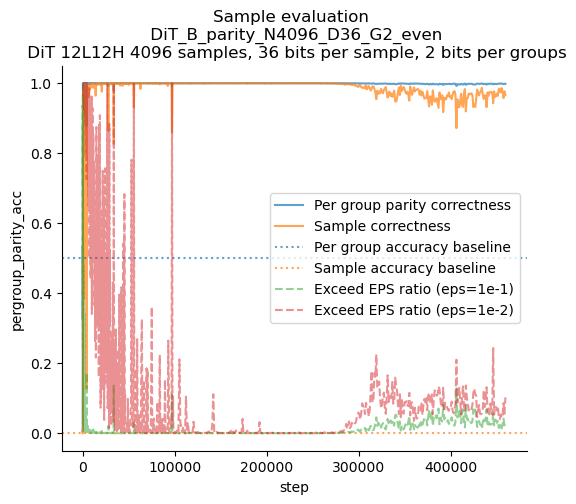

step: 456352, Per group parity correctness: 24404, Sample correctness: 1882 nan: 81| total: 2048: 100%|██████████| 940/940 [00:34<00:00, 27.11it/s] 


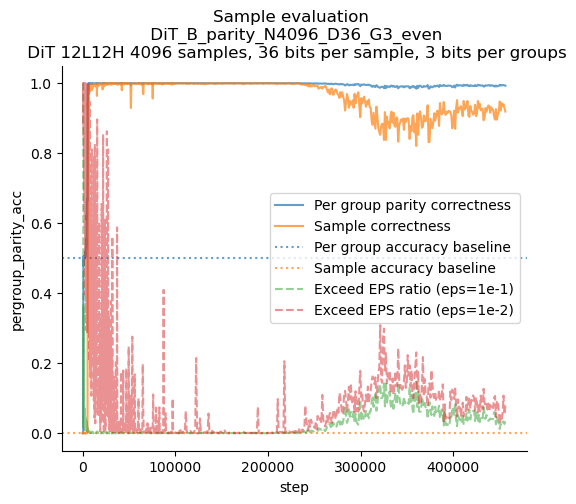

step: 459424, Per group parity correctness: 18306, Sample correctness: 1924 nan: 7| total: 2048: 100%|██████████| 943/943 [00:35<00:00, 26.62it/s]  


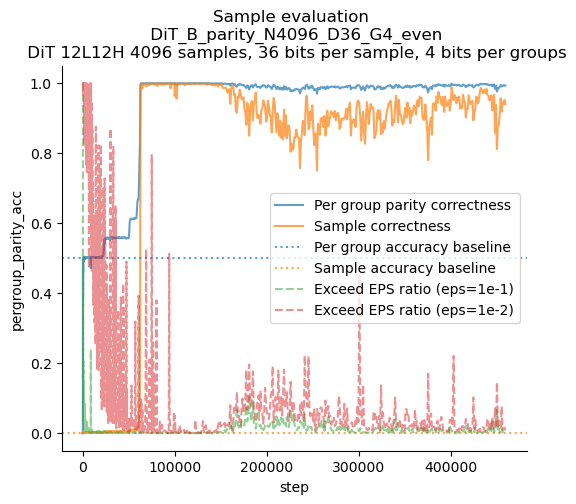

step: 459424, Per group parity correctness: 12056, Sample correctness: 1827 nan: 5| total: 2048: 100%|██████████| 943/943 [00:35<00:00, 26.46it/s]  


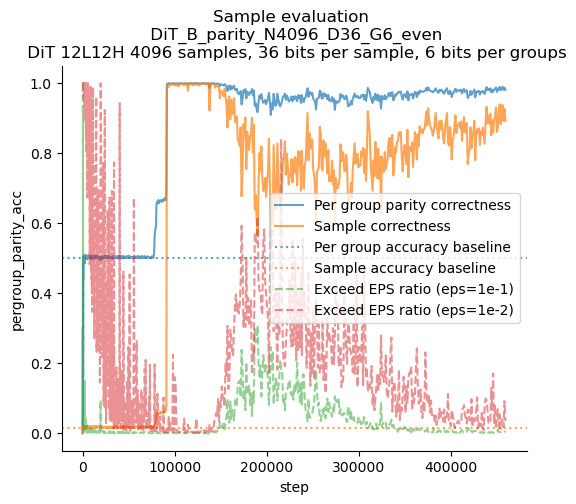

step: 464544, Per group parity correctness: 6714, Sample correctness: 1201 nan: 11| total: 2048: 100%|██████████| 948/948 [00:35<00:00, 26.81it/s] 


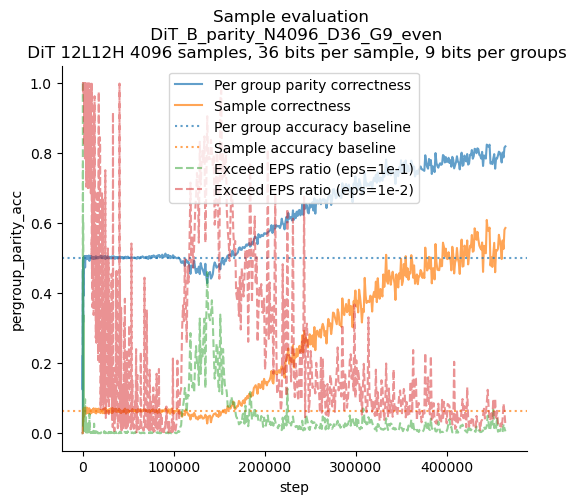

step: 462496, Per group parity correctness: 4291, Sample correctness: 840 nan: 26| total: 2048: 100%|██████████| 946/946 [00:33<00:00, 28.20it/s] 


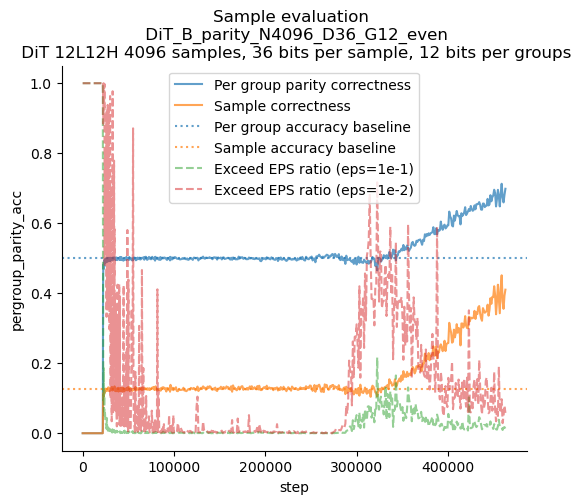

step: 457376, Per group parity correctness: 3082, Sample correctness: 1239 nan: 53| total: 2048: 100%|██████████| 941/941 [00:31<00:00, 30.31it/s] 


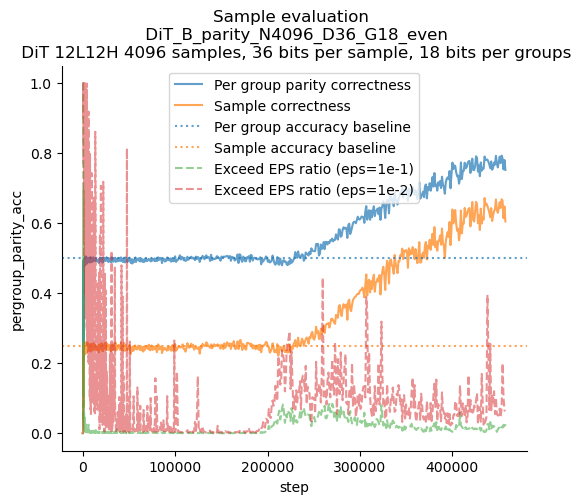

step: 460448, Per group parity correctness: 1539, Sample correctness: 1539 nan: 53| total: 2048: 100%|██████████| 944/944 [00:32<00:00, 29.10it/s] 


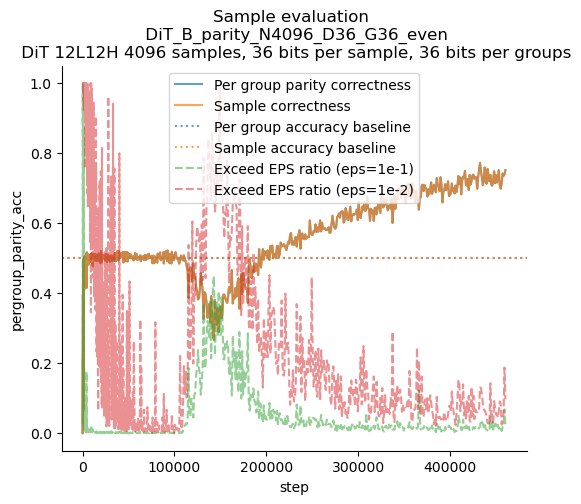

In [7]:
saveroot = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
eval_stats_df_all = []
for exp_name in [
                #
                'DiT_B_parity_N4096_D36_G2_even',
                'DiT_B_parity_N4096_D36_G3_even',
                'DiT_B_parity_N4096_D36_G4_even',
                'DiT_B_parity_N4096_D36_G6_even',
                'DiT_B_parity_N4096_D36_G9_even',
                'DiT_B_parity_N4096_D36_G12_even',
                'DiT_B_parity_N4096_D36_G18_even',
                'DiT_B_parity_N4096_D36_G36_even',
                #
                # 'DiT_nano_parity_N4096_D36_G2_even',
                # 'DiT_nano_parity_N4096_D36_G3_even',
                # 'DiT_nano_parity_N4096_D36_G4_even',
                # 'DiT_nano_parity_N4096_D36_G6_even',
                # 'DiT_nano_parity_N4096_D36_G9_even',
                # 'DiT_nano_parity_N4096_D36_G12_even',
                # 'DiT_nano_parity_N4096_D36_G18_even',
                # 'DiT_nano_parity_N4096_D36_G36_even',
                # # 
                # 'DiT_mini_parity_N4096_D36_G2_even',
                # 'DiT_mini_parity_N4096_D36_G3_even',
                # 'DiT_mini_parity_N4096_D36_G4_even',
                # 'DiT_mini_parity_N4096_D36_G6_even',
                # 'DiT_mini_parity_N4096_D36_G9_even',
                # 'DiT_mini_parity_N4096_D36_G12_even',
                # 'DiT_mini_parity_N4096_D36_G18_even',
                # 'DiT_mini_parity_N4096_D36_G36_even',
                ]:
    savedir = f"{saveroot}/{exp_name}"
    sample_dir = f"{savedir}/samples"
    ckpt_dir = f"{savedir}/ckpts"
    args = edict(json.load(open(f"{savedir}/args.json")))
    config = json.load(open(f"{savedir}/config.json"))
    train_sample_num = args.sample_num
    sample_len = args.sample_len
    group_size = args.group_size
    num_groups = sample_len // group_size
    nlayer = config["depth"]
    nhead  = config["num_heads"]
    parity = args.parity
    eval_stats = []
    all_steps = get_all_available_steps(sample_dir, excluded_steps=[])
    pbar = tqdm(all_steps)
    for step in pbar:
        sample_tsr = th.load(f"{sample_dir}/samples_epoch_{step:06d}.pt", weights_only=False)
        eval_sample_num = sample_tsr.shape[0]
        eps = 1e-2
        sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
        exist_nan = th.sum(sample_tsr_int.flatten(start_dim=1), dim=1)
        nan_num_eps_1e_2 = th.sum(th.isnan(exist_nan)).item()
        nan_ratio_eps_1e_2 = nan_num_eps_1e_2 / eval_sample_num
        
        eps = 1e-1
        sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
        exist_nan = th.sum(sample_tsr_int.flatten(start_dim=1), dim=1)
        nan_num_eps_1e_1 = th.sum(th.isnan(exist_nan)).item()
        nan_ratio_eps_1e_1 = nan_num_eps_1e_1 / eval_sample_num
        # reshape to group as last dimension
        sample_pergroup_int = sample_tsr_int.reshape(eval_sample_num, num_groups, group_size)
        sample_eval_parity = parity_func(sample_pergroup_int, axis=-1)
        # count parity correctness for each group
        pergroup_parity_correctness = th.sum(sample_eval_parity == parity).sum()
        pergroup_parity_correctness_ratio = pergroup_parity_correctness / (eval_sample_num * num_groups)
        # count sample correct only when all groups are correct
        sample_correctness = th.all(sample_eval_parity == parity, dim=1).sum()
        sample_correctness_ratio = sample_correctness / eval_sample_num
        pbar.set_description(f"step: {step}, Per group parity correctness: {pergroup_parity_correctness}, Sample correctness: {sample_correctness} nan: {nan_num_eps_1e_1}| total: {eval_sample_num}")
        
        # correct_parity_pergroup = th.sum(sample_eval_parity == 0, axis=-1) / group_size
        # correct_parity_pergroup_ratio = correct_parity_pergroup / num_groups
        # correct_parity_pergroup_ratio_ratio = correct_parity_pergroup_ratio / group_size
        # nan_pergroup = th.sum(th.isnan(sample_eval_parity), axis=-1)
        # nan_pergroup_ratio = nan_pergroup / num_groups
        # nan_pergroup_ratio_ratio = nan_pergroup_ratio / group_size
        # print(f"Even parity: {even_parity_num_eps_1e_1}, Odd parity: {odd_parity_num_eps_1e_1} nan: {nan_num_eps_1e_1}| total: {sample_num}")
        # eps = 1e-2
        # sample_tsr_int = round_to_pos_neg_one(sample_tsr, eps=eps)
        # sample_eval_parity = parity_func(sample_tsr_int.flatten(1), axis=1)
        # sample_num = len(sample_eval_parity)
        # even_parity_num_eps_1e_2 = th.sum(sample_eval_parity == 0).item()
        # odd_parity_num_eps_1e_2 = th.sum(sample_eval_parity == 1).item()
        # nan_num_eps_1e_2 = th.sum(th.isnan(sample_eval_parity)).item()
        # print(f"Even parity: {even_parity_num_eps_1e_2}, Odd parity: {odd_parity_num_eps_1e_2} nan: {nan_num_eps_1e_2}| total: {sample_num}")
        eval_stats.append({
            "step": step,
            "sample_num": eval_sample_num,
            "group_size": group_size,
            "nan_num_eps_1e-1": nan_num_eps_1e_1,
            "nan_ratio_eps_1e-1": nan_ratio_eps_1e_1,
            "nan_num_eps_1e-2": nan_num_eps_1e_2,
            "nan_ratio_eps_1e-2": nan_ratio_eps_1e_2,
            "pergroup_parity_num": pergroup_parity_correctness.item(),
            "pergroup_parity_acc": pergroup_parity_correctness_ratio.item(),
            "sample_corr_num": sample_correctness.item(),
            "sample_corr_acc": sample_correctness_ratio.item(),
        })
    # th.save(eval_stats, f"{savedir}/eval_stats.pt")
    eval_stats_df = pd.DataFrame(eval_stats)
    eval_stats_df.to_csv(f"{savedir}/pergroup_eval_stats.csv", index=False)
    eval_stats_df["exp_name"] = exp_name
    eval_stats_df["group_size"] = group_size
    eval_stats_df_all.append(eval_stats_df)
    plt.figure(figsize=(6, 5))
    sns.lineplot(eval_stats_df, x="step", y="pergroup_parity_acc",  label="Per group parity correctness", alpha=0.7) # hue="group_size",
    sns.lineplot(eval_stats_df, x="step", y="sample_corr_acc",  label="Sample correctness", alpha=0.7) # hue="group_size",
    plt.axhline(y=0.5, linestyle=":", label="Per group accuracy baseline", color="C0", alpha=0.7)
    plt.axhline(y=0.5 ** num_groups, linestyle=":", label="Sample accuracy baseline", color="C1", alpha=0.7)
    sns.lineplot(eval_stats_df, x="step", y="nan_ratio_eps_1e-1",  label="Exceed EPS ratio (eps=1e-1)", alpha=0.5, linestyle="--") # hue="group_size",
    sns.lineplot(eval_stats_df, x="step", y="nan_ratio_eps_1e-2",  label="Exceed EPS ratio (eps=1e-2)", alpha=0.5, linestyle="--") # hue="group_size",
    plt.title(f"Sample evaluation \n {exp_name}\n DiT {nlayer}L{nhead}H {train_sample_num} samples, {sample_len} bits per sample, {group_size} bits per groups")
    plt.legend()
    saveallforms([synopsis_dir, savedir], f"{exp_name}_sample_parity_eval")
    plt.show()
# eval_stats_df_all = pd.concat(eval_stats_df_all)
# eval_stats_df_all.to_csv(f"{saveroot}/pergroup_eval_stats_all_exps.csv", index=False)
# eval_stats_df_all.to_csv(f"{synopsis_dir}/pergroup_eval_stats_all_exps.csv", index=False)

### Eval summary

In [8]:
eval_stats_df_all = pd.read_csv(f"{saveroot}/pergroup_eval_stats_all_exps.csv", index_col=False)

In [89]:
0.5 ** num_groups

0.5

In [28]:
eval_stats_df_all.query("exp_name == 'DiT_nano_parity_N4096_D36_G3_even'")

,step,sample_num,group_size,nan_num_eps_1e-1,nan_ratio_eps_1e-1,nan_num_eps_1e-2,nan_ratio_eps_1e-2,pergroup_parity_num,pergroup_parity_acc,sample_corr_num,sample_corr_acc,exp_name
0,1,2048,3,2048,1.000000,2048,1.000000,10,0.000407,0,0.000000,DiT_nano_parity_N4096_D36_G3_even
1,2,2048,3,2048,1.000000,2048,1.000000,12,0.000488,0,0.000000,DiT_nano_parity_N4096_D36_G3_even
2,3,2048,3,2048,1.000000,2048,1.000000,12,0.000488,0,0.000000,DiT_nano_parity_N4096_D36_G3_even
3,4,2048,3,2048,1.000000,2048,1.000000,13,0.000529,0,0.000000,DiT_nano_parity_N4096_D36_G3_even
4,5,2048,3,2048,1.000000,2048,1.000000,14,0.000570,0,0.000000,DiT_nano_parity_N4096_D36_G3_even
...,...,...,...,...,...,...,...,...,...,...,...,...
978,496288,2048,3,3,0.001465,5,0.002441,24572,0.999837,2044,0.998047,DiT_nano_parity_N4096_D36_G3_even
979,497312,2048,3,3,0.001465,7,0.003418,24568,0.999674,2040,0.996094,DiT_nano_parity_N4096_D36_G3_even
980,498336,2048,3,2,0.000977,5,0.002441,24567,0.999634,2039,0.995605,DiT_nano_parity_N4096_D36_G3_even
981,499360,2048,3,2,0.000977,6,0.002930,24570,0.999756,2042,0.997070,DiT_nano_parity_N4096_D36_G3_even


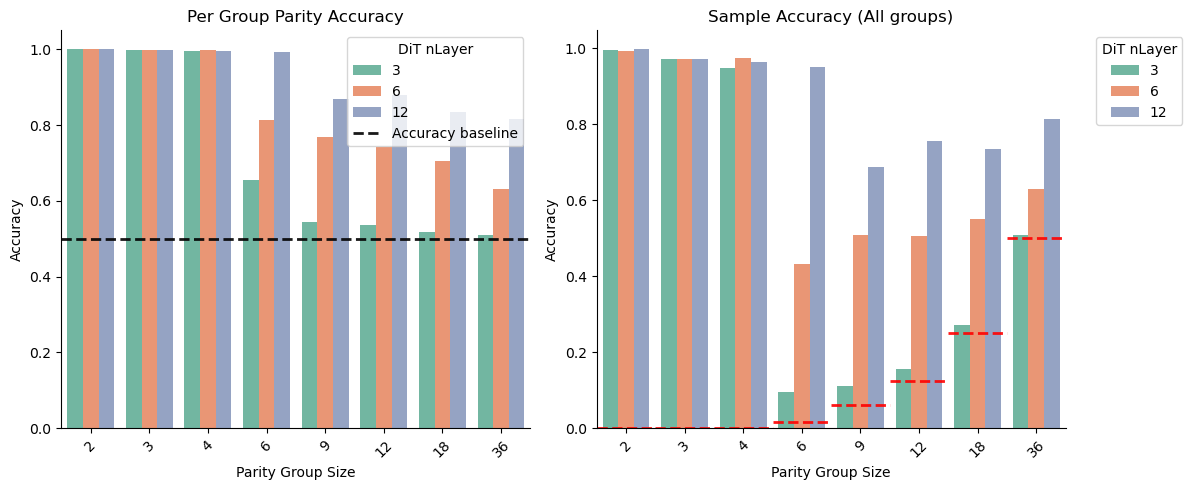

In [ ]:
final_stats = eval_stats_df_all.query("step == 1000000") # step == 500000 or 
# final_stats = eval_stats_df_all.query("step == 499360")
final_stats = final_stats.copy()
final_stats["layer_num"] = final_stats["exp_name"].apply(lambda x: 12 if "DiT_S" in x else 6 if "DiT_mini" in x else 3 if "DiT_nano" in x else None)
# print(final_stats)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=final_stats, x="group_size", y="pergroup_parity_acc", hue="layer_num", palette="Set2")
plt.axhline(y=0.5, linestyle="--", label="Accuracy baseline", color="k", alpha=0.9, linewidth=2)
plt.title("Per Group Parity Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Parity Group Size")
plt.xticks(rotation=45)
plt.legend(title="DiT nLayer")
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.subplot(1, 2, 2)
sns.barplot(data=final_stats, x="group_size", y="sample_corr_acc", hue="layer_num", palette="Set2")
for i, group_size in enumerate(final_stats["group_size"].unique()):
    num_groups = 36 // group_size
    plt.axhline(y=0.5 ** num_groups, linestyle="--", color="r", alpha=0.9, linewidth=2, 
                xmin=i / len(final_stats["group_size"].unique()), xmax=(i+1)/len(final_stats["group_size"].unique()))
plt.title("Sample Accuracy (All groups)")
plt.ylabel("Accuracy")
plt.xlabel("Parity Group Size")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="DiT nLayer")
plt.tight_layout()
saveallforms(synopsis_dir, "parity_func_eval_all_exps_synopsis", fmts=["png", "pdf"])
plt.show()

In [17]:
# Find the step number closest to 100000
target_step = 500000
for target_step in [100000, 200352, 300000, 400000, 500000, 1000000]:
    step_diffs = abs(eval_stats_df_all['step'] - target_step)
    closest_step = eval_stats_df_all.loc[step_diffs.idxmin(), 'step']
    print(f"Step closest to {target_step}: {closest_step}")

Step closest to 100000: 100000
Step closest to 200352: 200352
Step closest to 300000: 299680
Step closest to 400000: 400032
Step closest to 500000: 500000
Step closest to 1000000: 1000000


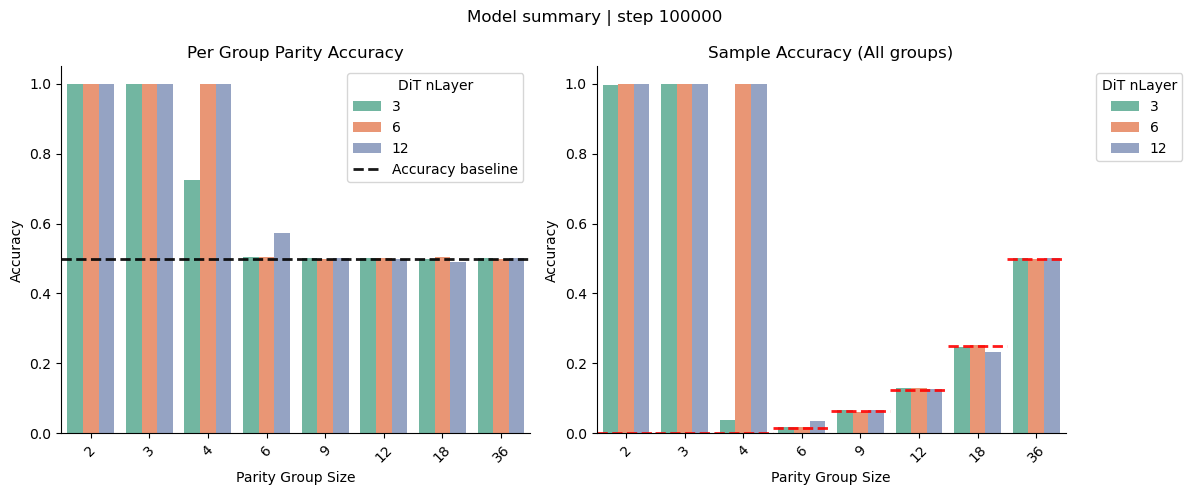

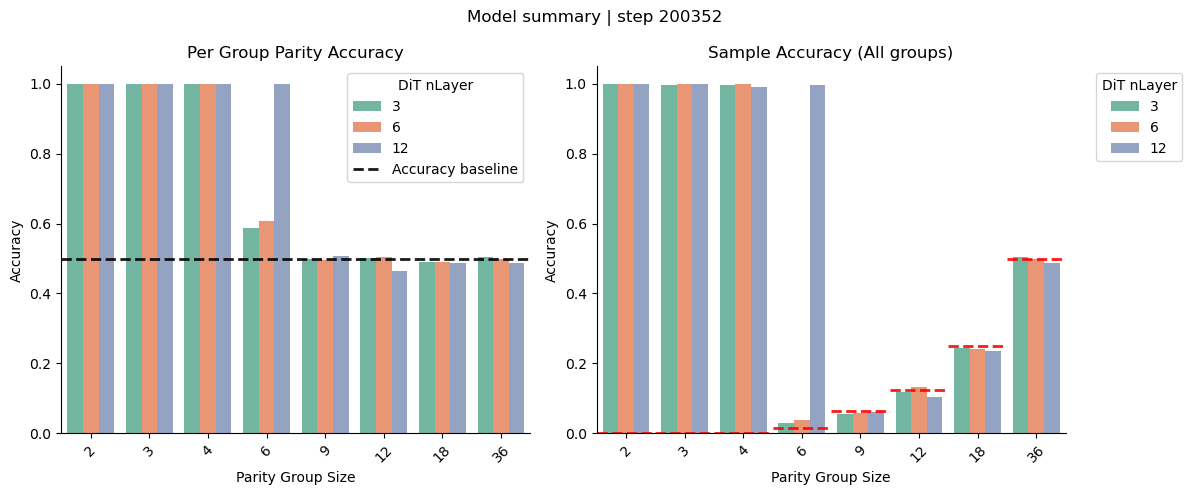

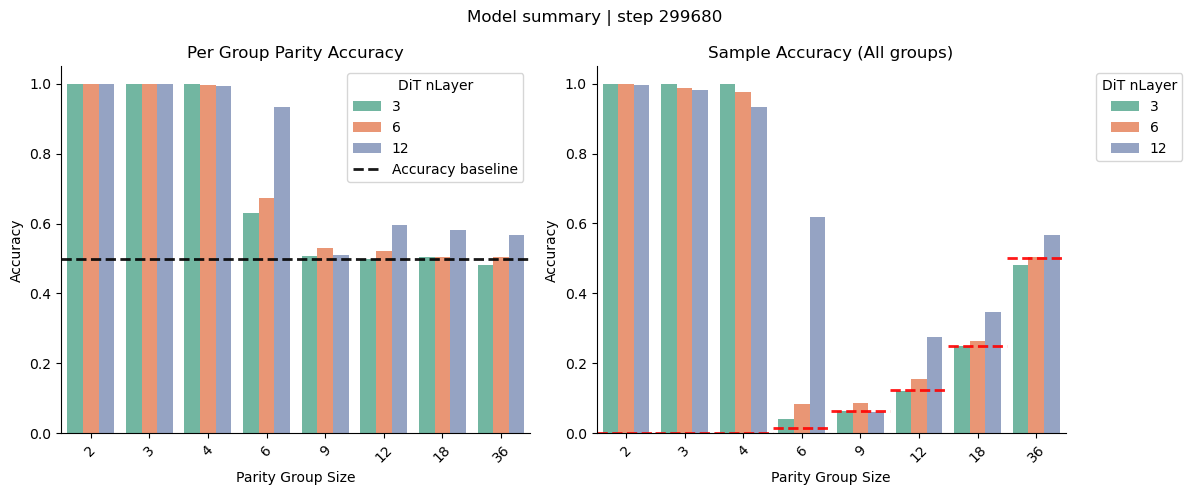

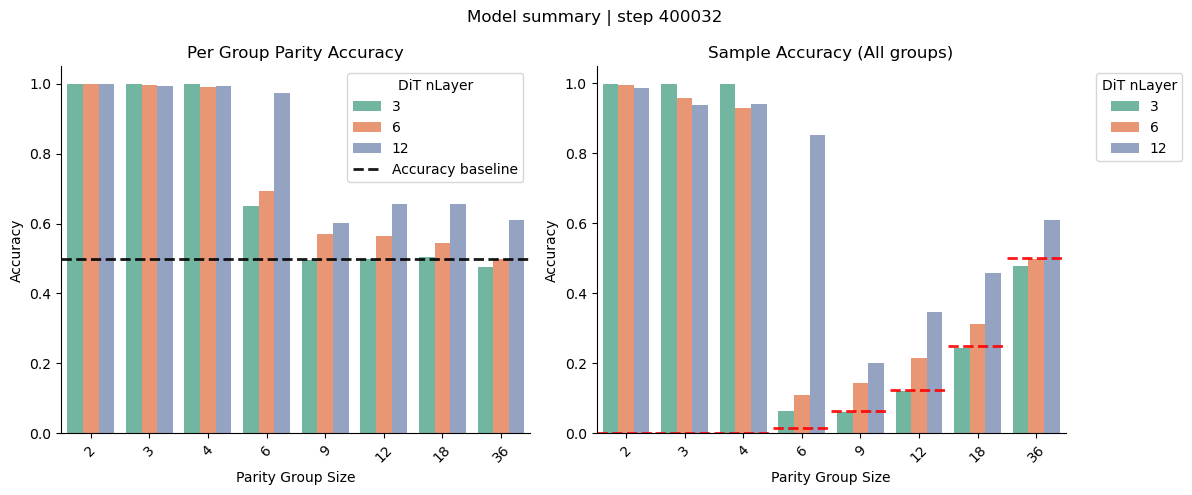

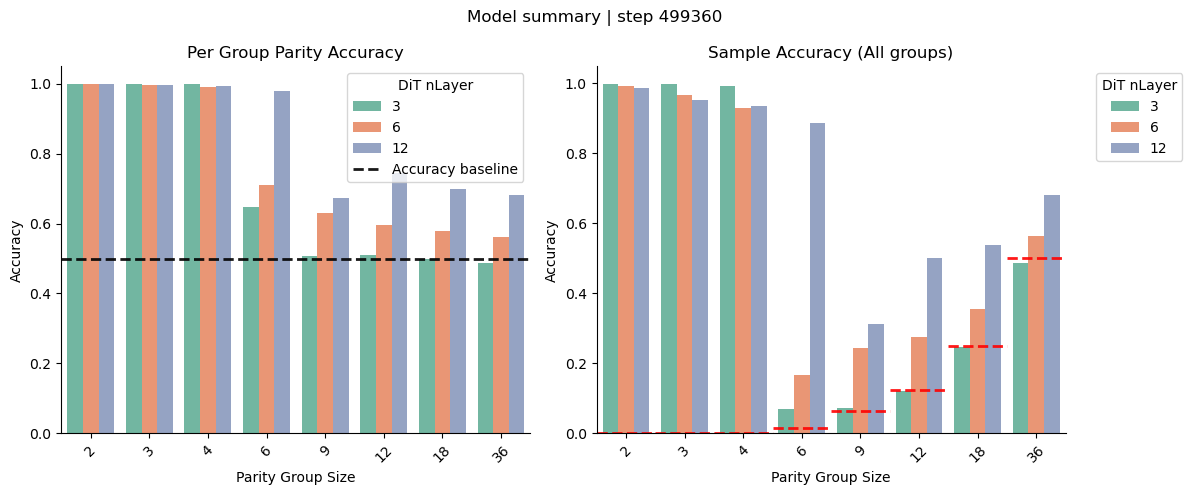

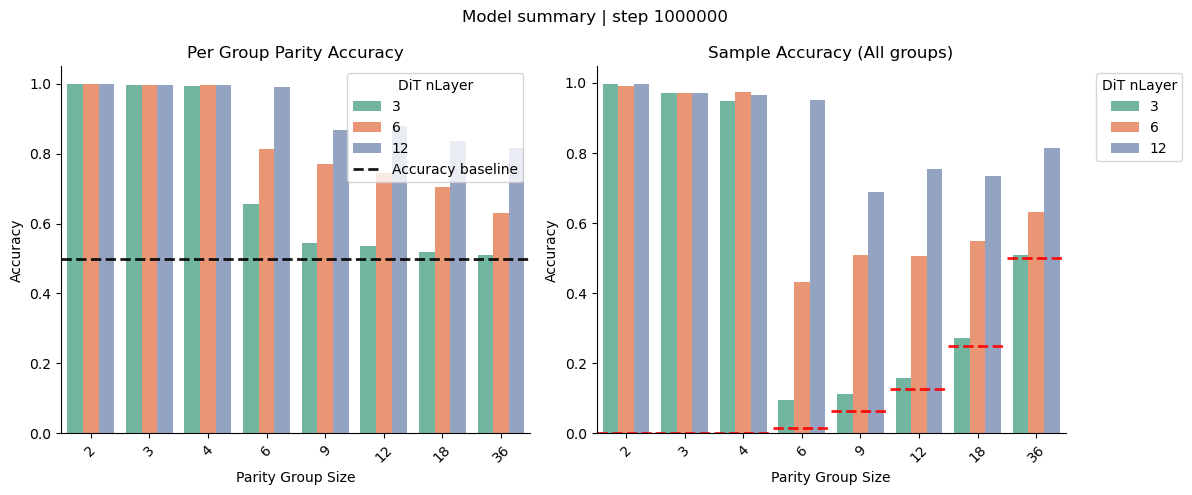

In [18]:
# final_stats = eval_stats_df_all.query("step == 500000 or step == 1000000")
# step_num = 200352
for step_num in [100000, 200352, 299680, 400032, 499360, 1000000]:
    final_stats = eval_stats_df_all.query(f"step == {step_num}")
    final_stats = final_stats.copy()
    final_stats["layer_num"] = final_stats["exp_name"].apply(lambda x: 12 if "DiT_S" in x else 6 if "DiT_mini" in x else 3 if "DiT_nano" in x else None)
    # print(final_stats)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.barplot(data=final_stats, x="group_size", y="pergroup_parity_acc", hue="layer_num", palette="Set2")
    plt.axhline(y=0.5, linestyle="--", label="Accuracy baseline", color="k", alpha=0.9, linewidth=2)
    plt.title("Per Group Parity Accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("Parity Group Size")
    plt.xticks(rotation=45)
    plt.legend(title="DiT nLayer")
    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.subplot(1, 2, 2)
    sns.barplot(data=final_stats, x="group_size", y="sample_corr_acc", hue="layer_num", palette="Set2")
    for i, group_size in enumerate(final_stats["group_size"].unique()):
        num_groups = 36 // group_size
        plt.axhline(y=0.5 ** num_groups, linestyle="--", color="r", alpha=0.9, linewidth=2, 
                    xmin=i / len(final_stats["group_size"].unique()), xmax=(i+1)/len(final_stats["group_size"].unique()))
    plt.title("Sample Accuracy (All groups)")
    plt.ylabel("Accuracy")
    plt.xlabel("Parity Group Size")
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="DiT nLayer")
    plt.suptitle(f"Model summary | step {step_num}")
    plt.tight_layout()
    saveallforms(synopsis_dir, f"parity_func_eval_all_exps_synopsis_step{step_num}", fmts=["png", "pdf"])
    plt.show()

In [ ]:
# final_stats = eval_stats_df_all.query("step == 500000 or step == 1000000")
final_stats = eval_stats_df_all.query("step == 499360")
final_stats = final_stats.copy()
final_stats["layer_num"] = final_stats["exp_name"].apply(lambda x: 12 if "DiT_S" in x else 6 if "DiT_mini" in x else 3 if "DiT_nano" in x else None)
# print(final_stats)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=final_stats, x="group_size", y="pergroup_parity_acc", hue="layer_num", palette="Set2")
plt.axhline(y=0.5, linestyle="--", label="Accuracy baseline", color="k", alpha=0.9, linewidth=2)
plt.title("Per Group Parity Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Parity Group Size")
plt.xticks(rotation=45)
plt.legend(title="DiT nLayer")
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.subplot(1, 2, 2)
sns.barplot(data=final_stats, x="group_size", y="sample_corr_acc", hue="layer_num", palette="Set2")
for i, group_size in enumerate(final_stats["group_size"].unique()):
    num_groups = 36 // group_size
    plt.axhline(y=0.5 ** num_groups, linestyle="--", color="r", alpha=0.9, linewidth=2, 
                xmin=i / len(final_stats["group_size"].unique()), xmax=(i+1)/len(final_stats["group_size"].unique()))
plt.title("Sample Accuracy (All groups)")
plt.ylabel("Accuracy")
plt.xlabel("Parity Group Size")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="DiT nLayer")
plt.tight_layout()
saveallforms(synopsis_dir, "parity_func_eval_all_exps_synopsis_step499360", fmts=["png", "pdf"])
plt.show()

### Loss comparison

In [59]:
import pickle as pkl

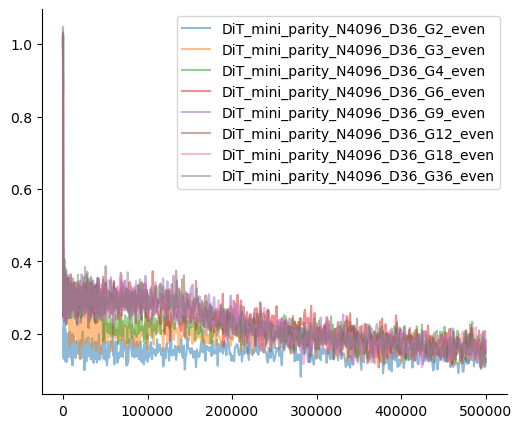

In [61]:
saveroot = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
eval_stats_df_all = []
plt.figure(figsize=(6, 5))
for exp_name in ['DiT_mini_parity_N4096_D36_G2_even',
                'DiT_mini_parity_N4096_D36_G3_even',
                'DiT_mini_parity_N4096_D36_G4_even',
                'DiT_mini_parity_N4096_D36_G6_even',
                'DiT_mini_parity_N4096_D36_G9_even',
                'DiT_mini_parity_N4096_D36_G12_even',
                'DiT_mini_parity_N4096_D36_G18_even',
                'DiT_mini_parity_N4096_D36_G36_even',]:
    savedir = f"{saveroot}/{exp_name}"
    loss_store = pkl.load(open(f"{savedir}/loss_store.pkl", "rb"))
    plt.plot(loss_store.keys(), loss_store.values(), label=exp_name, alpha=0.5)
plt.legend()
plt.show()

### Final sample comparison

In [63]:
from PIL import Image

DiT_mini_parity_N4096_D36_G2_even


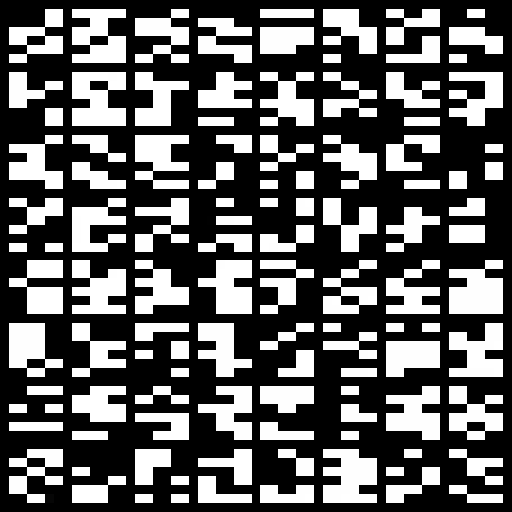

DiT_mini_parity_N4096_D36_G3_even


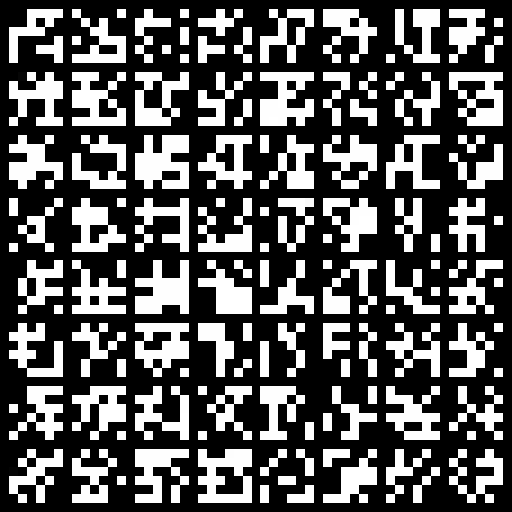

DiT_mini_parity_N4096_D36_G4_even


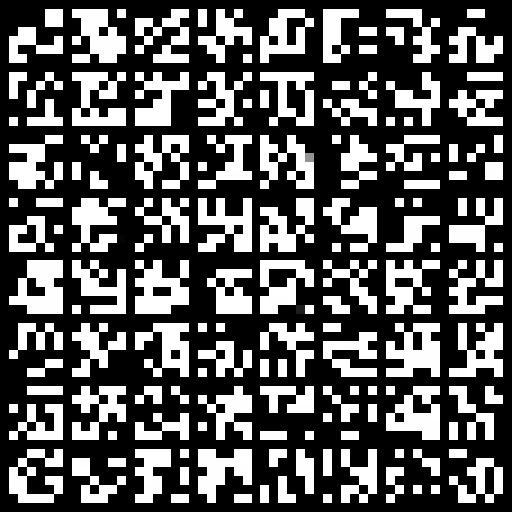

DiT_mini_parity_N4096_D36_G6_even


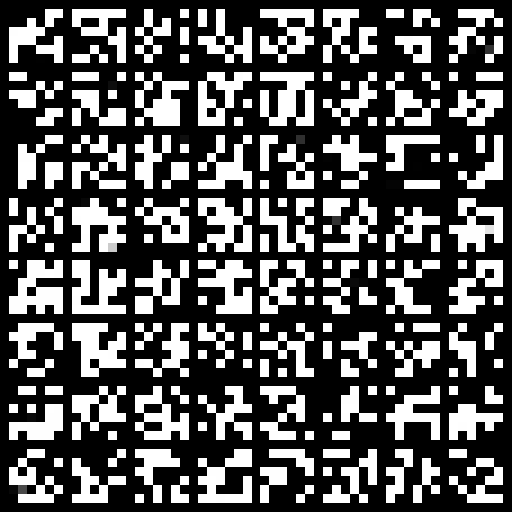

DiT_mini_parity_N4096_D36_G9_even


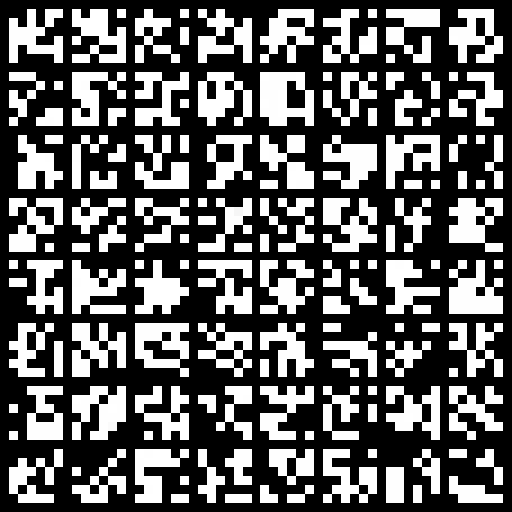

DiT_mini_parity_N4096_D36_G12_even


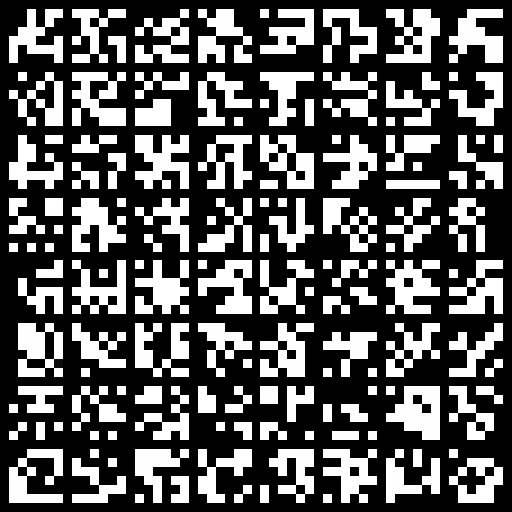

DiT_mini_parity_N4096_D36_G18_even


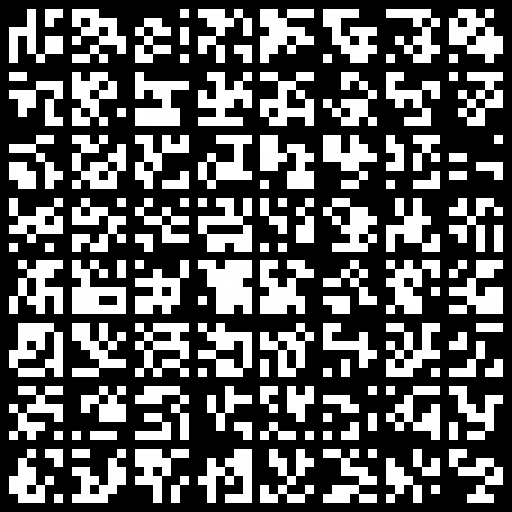

DiT_mini_parity_N4096_D36_G36_even


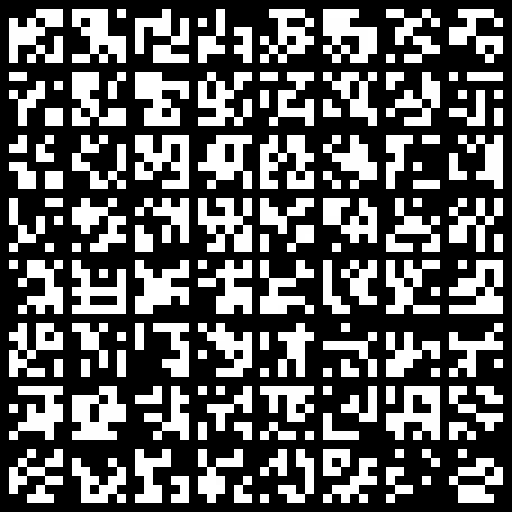

In [68]:
saveroot = f"/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
# eval_stats_df_all = []
# plt.figure(figsize=(6, 5))
for exp_name in ['DiT_mini_parity_N4096_D36_G2_even',
                'DiT_mini_parity_N4096_D36_G3_even',
                'DiT_mini_parity_N4096_D36_G4_even',
                'DiT_mini_parity_N4096_D36_G6_even',
                'DiT_mini_parity_N4096_D36_G9_even',
                'DiT_mini_parity_N4096_D36_G12_even',
                'DiT_mini_parity_N4096_D36_G18_even',
                'DiT_mini_parity_N4096_D36_G36_even',]:
    savedir = f"{saveroot}/{exp_name}"
    sample_dir = f"{savedir}/samples"
    print(exp_name)
    display(Image.open(f"{sample_dir}/samples_epoch_500000.png").resize((512, 512), Image.Resampling.NEAREST))
    
    # loss_store = pkl.load(open(f"{savedir}/loss_store.pkl", "rb"))
    # plt.plot(loss_store.keys(), loss_store.values(), label=exp_name, alpha=0.5)
# plt.legend()
# plt.show()

### Scratch

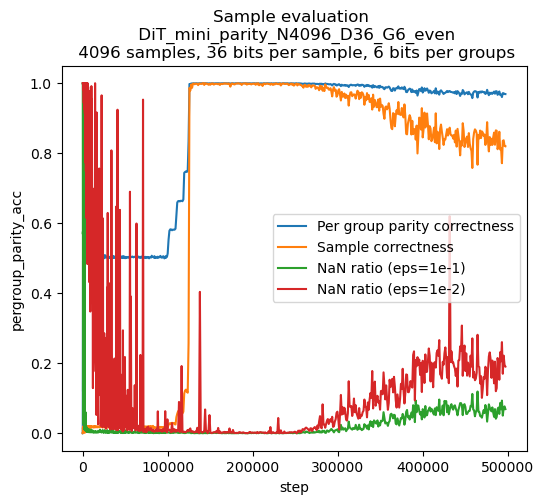

In [ ]:
plt.figure(figsize=(6, 5))
sns.lineplot(eval_stats_df, x="step", y="pergroup_parity_acc",  label="Per group parity correctness") # hue="group_size",
sns.lineplot(eval_stats_df, x="step", y="sample_corr_acc",  label="Sample correctness") # hue="group_size",
sns.lineplot(eval_stats_df, x="step", y="nan_ratio_eps_1e-1",  label="NaN ratio (eps=1e-1)") # hue="group_size",
sns.lineplot(eval_stats_df, x="step", y="nan_ratio_eps_1e-2",  label="NaN ratio (eps=1e-2)") # hue="group_size",
plt.title(f"Sample evaluation \n {exp_name}\n {sample_num} samples, {sample_len} bits per sample, {group_size} bits per groups")
plt.legend()
saveallforms(synopsis_dir, f"{exp_name}_sample_parity_eval")
plt.show()


In [32]:
num_groups

6

In [33]:
group_size

6